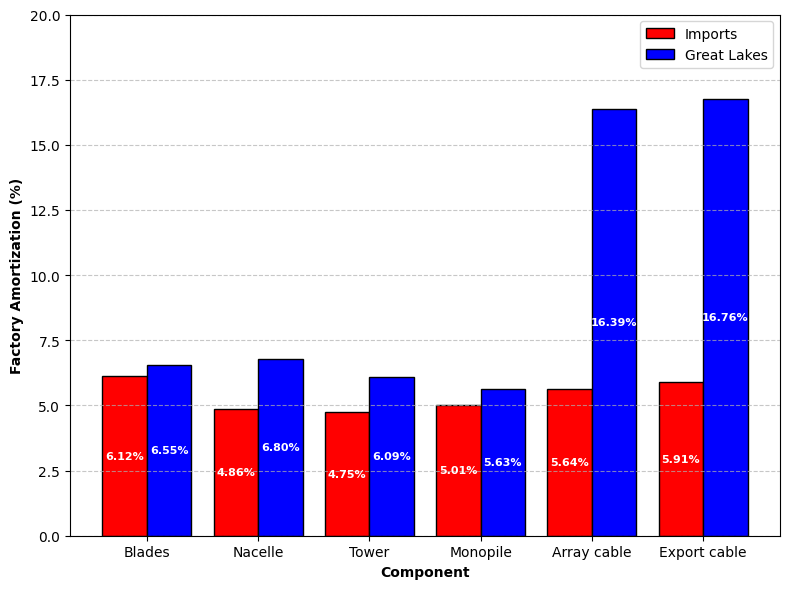

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('data/sales_premium.csv')

# Convert percentage strings to float
df['Imports'] = df['Imports'].str.rstrip('%').astype(float)
df['Great Lakes'] = df['Great Lakes'].str.rstrip('%').astype(float)

# Plot configuration
fig, ax = plt.subplots(figsize=(8, 6))
x = range(len(df))
width = 0.4  # Width of the bars

# Create bars
bars_imports = ax.bar([i - width/2 for i in x], df['Imports'], width=width, label='Imports', color='red', edgecolor='black')
bars_great_lakes = ax.bar([i + width/2 for i in x], df['Great Lakes'], width=width, label='Great Lakes', color='blue', edgecolor='black')

# Add white text labels at the center height of each bar
for bar in bars_imports:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2, f'{bar.get_height():.2f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=8)
for bar in bars_great_lakes:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2, f'{bar.get_height():.2f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=8)

# Labels and formatting
ax.set_xticks(x)
ax.set_xticklabels(df['Sales Premium'], rotation=0, ha='center')
ax.set_ylabel('Factory Amortization (%)', fontweight='bold')
ax.set_xlabel('Component', fontweight='bold')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_ylim(0, 20)

# Show the plot
plt.tight_layout()

plt.savefig("figures/sales_premium.svg", format="svg", dpi=300)

plt.show()


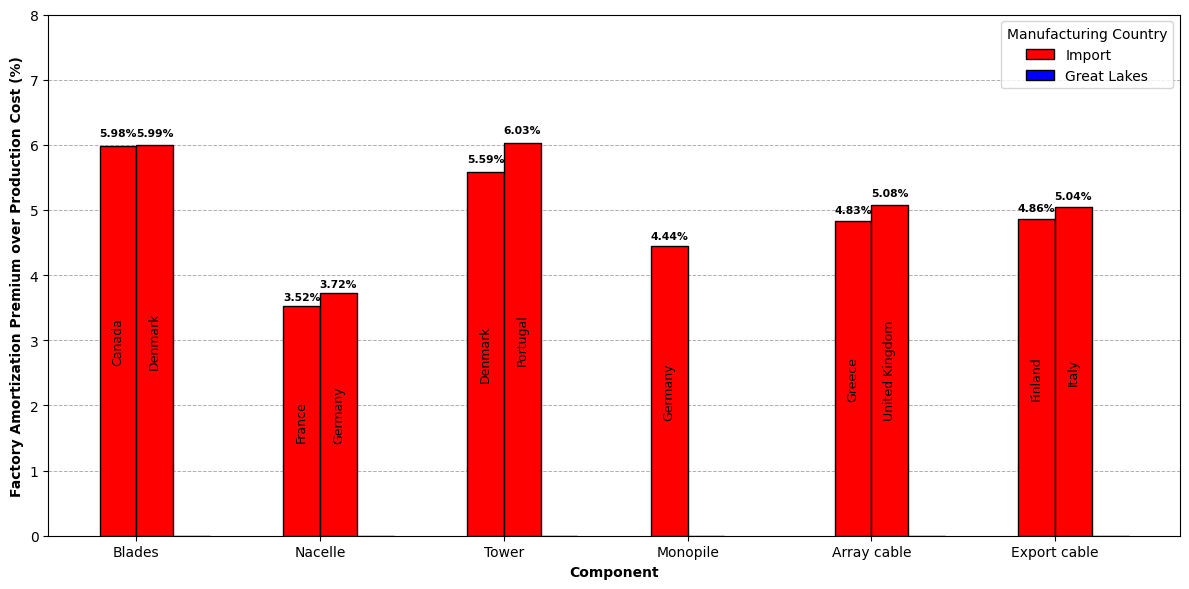

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('data/sales_premium_just_imports.csv')

# Convert 'Factory Amortization' to numeric values (removing the '%' symbol)
df['Factory Amortization'] = df['Factory Amortization'].replace({'%': ''}, regex=True).astype(float)

# Initialize a new column 'Country Type' to label Great Lakes as 'Great Lakes' and others as 'Import'
df['Country Type'] = df['Manufacturing Country'].apply(lambda x: 'Great Lakes' if x == 'Great Lakes' else 'Import')

# Create a figure
plt.figure(figsize=(12, 6))

# Set the width for the bars
width = 0.2  # Width of the bars, adjusted to fit multiple bars

# Get unique components
components = df['Component'].unique()

# Define colors for "Great Lakes" and "Import"
colors = {'Great Lakes': 'blue', 'Import': 'red'}

# Create a bar plot for each component
for i, component in enumerate(components):
    component_data = df[df['Component'] == component]
    
    # First plot all non-Great Lakes countries
    for j, (country, country_data) in enumerate(component_data[component_data['Manufacturing Country'] != 'Great Lakes'].groupby('Manufacturing Country')):
        country_type = country_data['Country Type'].values[0]
        
        # Plot each country with the corresponding factory amortization
        bar_height = country_data['Factory Amortization'].values[0]
        bar = plt.bar(i + (j - 0.5) * width, bar_height, width,
                      label="Import" if i == 0 and j == 0 else "",  # Only show the label once for "Import"
                      color=colors[country_type], edgecolor='black', zorder = 100)  # Add black edgecolor

        # Annotate each bar with the country's name inside the bar, vertically centered
        plt.text(i + (j - 0.5) * width, bar_height / 2, country, ha='center', va='center', fontsize=9, color='black', rotation=90, zorder = 110)

        # Add the percentage value on top of each bar
        plt.text(i + (j - 0.5) * width, bar_height * 1.02, f'{bar_height:.2f}%', ha='center', va='bottom', fontsize=7.75, color='black', zorder = 120, fontweight='bold')

    # Now plot the Great Lakes country last
    great_lakes_data = component_data[component_data['Manufacturing Country'] == 'Great Lakes']
    bar_height = great_lakes_data['Factory Amortization'].values[0]
    bar = plt.bar(i + (len(component_data['Manufacturing Country'].unique()) - 1 - 0.5) * width,
                  bar_height, width,
                  label="Great Lakes" if i == 0 else "",
                  color=colors['Great Lakes'], edgecolor='black', zorder = 100)  # Add black edgecolor

    # Add the percentage value on top of the "Great Lakes" bar
    #plt.text(i + (len(component_data['Manufacturing Country'].unique()) - 1 - 0.5) * width, bar_height + 0.2, 
    #         f'{bar_height:.2f}%', ha='center', va='bottom', fontsize=9, color='black', zorder=120)

# Set Y-axis limits from 0 to 8
plt.ylim(0, 8)

# Add labels 
plt.xlabel('Component', fontweight='bold')
plt.ylabel('Factory Amortization Premium over Production Cost (%)', fontweight='bold')
plt.xticks(range(len(components)), components)

# Display the legend
plt.legend(title='Manufacturing Country')

# Add horizontal gridlines
plt.grid(axis='y', linestyle='--', linewidth=0.7, zorder = 1)

# Adjust layout to make it look nice
plt.tight_layout()

plt.savefig("figures/sales_premium_just_imports.svg", format="svg", dpi=300)

# Display the plot
plt.show()
